### TASK 1-> DATA LOADING,MERGING & DEEP EXPOLARATION

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the Superstore Sales CSV
df=pd.read_csv("/Users/dhruvnagori/Desktop/SalesForecasting_DhruvNagori/train.csv")

print("Superstore dataset shape:", df.shape)

Superstore dataset shape: (9800, 18)


In [6]:
#Inspect the Dataset
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [7]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null  

In [8]:
print("\nStatistical Summary:")
display(df.describe(include="all"))


Statistical Summary:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


#### Observation from the dataset ->

The Superstore dataset contains 9,800 transaction records and 18 original variables. 
The variables include order information, shipping details, customer information, 
geographical attributes, product categories, and sales revenue.

Initial inspection shows that the date columns are stored as object/string values 
and therefore require conversion to datetime format before time-series analysis.

In [9]:
# Parse the Order Date and Ship Date columns as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],dayfirst=True, errors='coerce')

print(df[['Order Date', 'Ship Date']].head())
print("\nupdated Dataset Information:")
print(df[['Order Date', 'Ship Date']].dtypes)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18

updated Dataset Information:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [10]:
# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df['Week_Number'] = df['Order Date'].dt.isocalendar().week.astype('Int64')
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [11]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

In [12]:
df[["Order Date","Year","Month","Week_Number","Day_of_Week","Quarter","Season"]].head()

,Order Date,Year,Month,Week_Number,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


In [13]:
# Check for missing values
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
]

display(missing_table)

,Missing Values,Missing Percentage
Postal Code,11,0.112245


In [14]:
# Inspect rows where Postal Code is missing
missing_postal_rows = df[
    df["Postal Code"].isna()
][
    ["City", "State", "Region", "Country", "Postal Code"]
]

print("Rows with Missing Postal Code:")
display(missing_postal_rows)

Rows with Missing Postal Code:


,City,State,Region,Country,Postal Code
2234,Burlington,Vermont,East,United States,NaN
5274,Burlington,Vermont,East,United States,NaN
8798,Burlington,Vermont,East,United States,NaN
9146,Burlington,Vermont,East,United States,NaN
9147,Burlington,Vermont,East,United States,NaN
9148,Burlington,Vermont,East,United States,NaN
9386,Burlington,Vermont,East,United States,NaN
9387,Burlington,Vermont,East,United States,NaN
9388,Burlington,Vermont,East,United States,NaN
9389,Burlington,Vermont,East,United States,NaN


In [15]:
# Create a mapping using the most frequent Postal Code
# for each City-State combination

city_state_postal_map = (df.dropna(subset=["Postal Code"]).groupby(["City", "State"])["Postal Code"].agg(lambda x: x.mode().iloc[0]))
display(city_state_postal_map.head())

City         State       
Aberdeen     South Dakota    57401.0
Abilene      Texas           79605.0
Akron        Ohio            44312.0
Albuquerque  New Mexico      87105.0
Alexandria   Virginia        22304.0
Name: Postal Code, dtype: float64

In [16]:
# Check all Burlington records in the dataset
burlington_records = df[df["City"].str.strip().str.lower() == "burlington"][["City", "State", "Region", "Postal Code"]]
display(burlington_records)

,City,State,Region,Postal Code
683,Burlington,North Carolina,South,27217.0
684,Burlington,North Carolina,South,27217.0
1008,Burlington,Iowa,Central,52601.0
1038,Burlington,North Carolina,South,27217.0
1039,Burlington,North Carolina,South,27217.0
1393,Burlington,North Carolina,South,27217.0
2234,Burlington,Vermont,East,NaN
2928,Burlington,North Carolina,South,27217.0
5065,Burlington,North Carolina,South,27217.0
5066,Burlington,North Carolina,South,27217.0


In [17]:
# Check whether Burlington, Vermont has any known Postal Code
burlington_vermont = df[(df["City"].str.strip().str.lower() == "burlington") &(df["State"].str.strip().str.lower() == "vermont")][["City", "State", "Region", "Postal Code"]]

display(burlington_vermont)

print("Known Postal Codes for Burlington, Vermont:",burlington_vermont["Postal Code"].dropna().unique())

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


Known Postal Codes for Burlington, Vermont: []


### Missing Value Treatment

The dataset contains 11 missing values in the `Postal Code` column. Inspection showed
that all missing records belong to Burlington, Vermont.

An attempt was made to identify valid Postal Codes for the same City-State combination
from existing records in the dataset. However, no non-missing Postal Code was available
for Burlington, Vermont.

I have leave the missing values as it is and later if it is necessary i will fill the missing values according to the situtation

In [18]:
# Check for duplicates, and data type issues
exact_duplicates = df.duplicated().sum()
print("Exact Duplicate Rows:", exact_duplicates)

Exact Duplicate Rows: 0


In [19]:
print("Repeated Order IDs:", df["Order ID"].duplicated().sum())

Repeated Order IDs: 4878


### Duplicate Analysis

No exact duplicate rows were found in the dataset. Repeated Order IDs are not treated 
as duplicates because a single customer order may contain multiple product line items.
Therefore, no rows were removed based only on repeated Order IDs.

In [20]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month_Name               object
Week_Number               Int64
Day_of_Week              object
Quarter                   int32
Season                   object
dtype: object


In [21]:
print("Negative Sales Values:", (df["Sales"] < 0).sum())
print("Zero Sales Values:", (df["Sales"] == 0).sum())

Negative Sales Values: 0
Zero Sales Values: 0


In [22]:
invalid_shipping = df[
    df["Ship Date"] < df["Order Date"]
]
print(
    "Ship Date Earlier Than Order Date:",
    len(invalid_shipping)
)

Ship Date Earlier Than Order Date: 0


In [23]:
# Aggregate daily sales into weekly and monthly totals
daily_sales = (df.groupby("Order Date", as_index=False)["Sales"].sum().sort_values("Order Date"))
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [24]:
weekly_sales = (df.set_index("Order Date").resample("W-SUN")["Sales"].sum().reset_index())
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [25]:
monthly_sales = (df.set_index("Order Date").resample("MS")["Sales"].sum().reset_index())
monthly_sales.head()

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [26]:
print("Daily Sales Shape:", daily_sales.shape)
print("Weekly Sales Shape:", weekly_sales.shape)
print("Monthly Sales Shape:", monthly_sales.shape)

Daily Sales Shape: (1230, 2)
Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


#### Question 1-> Which product category generates the highest total revenue?

In [27]:
category_revenue = (df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
display(category_revenue)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

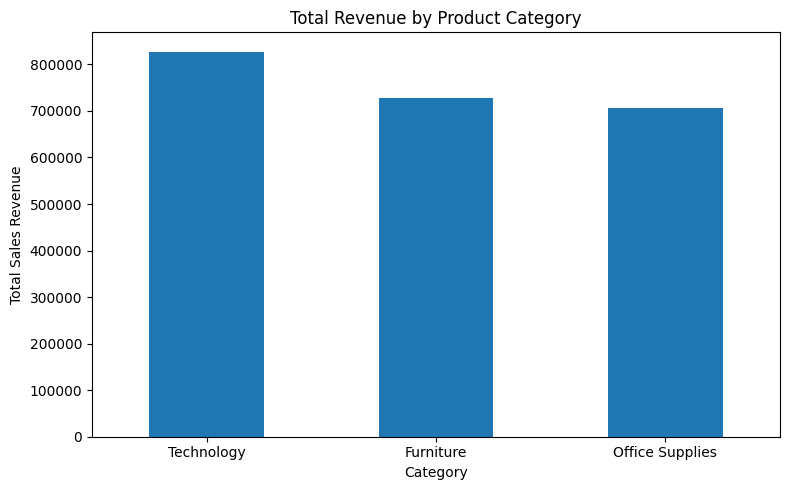

In [28]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 1: Highest Revenue-Generating Category

Technology generates the highest total revenue, with approximately 827,455.87 in 
sales. It is followed by Furniture at approximately 728,658.58 and Office Supplies 
at approximately 705,422.33. Therefore, Technology is the strongest category by 
overall sales revenue.

#### Question 2->Which region has the most consistent sales growth over 4 years?

In [29]:
region_year_sales = (df.groupby(["Year", "Region"])["Sales"].sum().unstack())
display(region_year_sales)

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


In [30]:
region_growth = (region_year_sales.pct_change(fill_method=None)* 100)
display(region_growth.round(2))

Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.48,20.03,-32.21,-8.36
2017,42.22,16.50,33.48,36.47
2018,-2.78,17.71,30.61,35.98


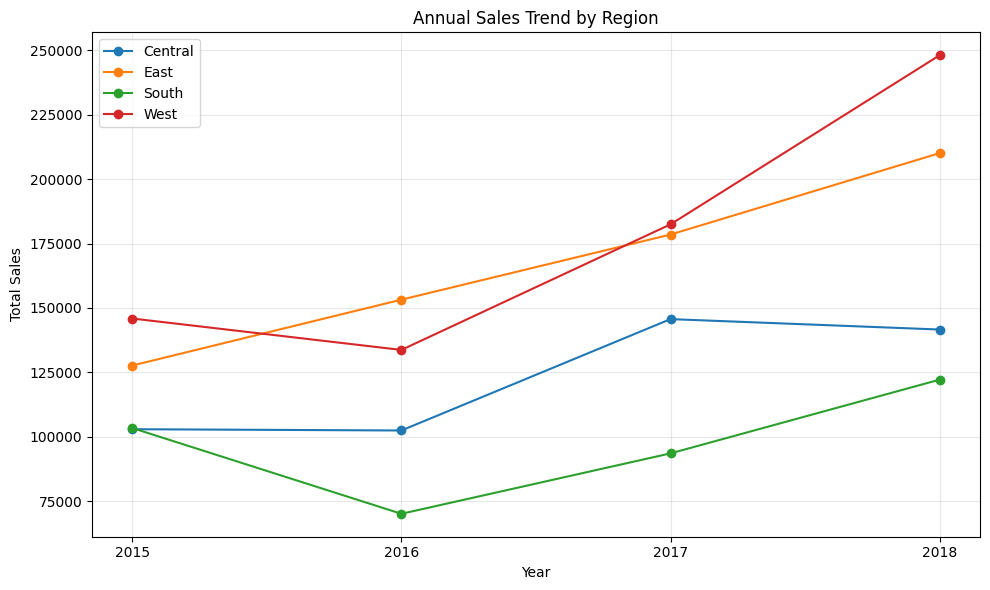

In [31]:
plt.figure(figsize=(10, 6))

for region in region_year_sales.columns:
    plt.plot(
        region_year_sales.index,
        region_year_sales[region],
        marker="o",
        label=region
    )

plt.title("Annual Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(region_year_sales.index)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Finding 2: Region with the Most Consistent Sales Growth

The East region demonstrates the most consistent sales growth across the four-year 
period. Its annual sales increase from approximately 127,652.82 in 2015 to 210,129.19 
in 2018, with positive year-over-year growth in every observed transition.

The East region recorded growth rates of approximately 20.03%, 16.50%, and 17.71%. 
Other regions experienced at least one year of declining sales. Therefore, East is 
identified as the region with the most consistent growth pattern.

#### Question 3->What is the average time between Order Date and Ship Date — and does it vary by region?


In [32]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

average_shipping_days = df["Shipping Days"].mean()
print("Overall Average Shipping Time:",round(average_shipping_days, 2),"days")

Overall Average Shipping Time: 3.96 days


In [33]:
regional_shipping = (df.groupby("Region")["Shipping Days"].agg(["mean", "median", "count"]).sort_values("mean"))
display(regional_shipping.round(2))

,mean,median,count
Region,,,
East,3.91,4.0,2785
West,3.93,4.0,3140
South,3.96,4.0,1598
Central,4.07,4.0,2277


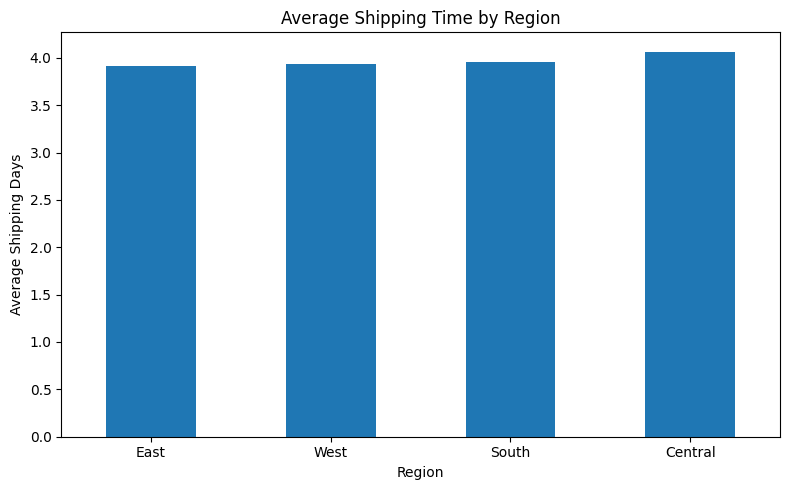

In [34]:
plt.figure(figsize=(8, 5))

regional_shipping["mean"].plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Finding 3: Average Order-to-Ship Time

The overall average time between Order Date and Ship Date is approximately 3.96 days.

Regional averages range from approximately 3.91 days in the East to 4.07 days in the 
Central region. This indicates only minor regional variation in shipping duration. 
The Central region is slightly slower on average, but the overall differences between 
regions are small.

#### Question 4->Are there months that consistently spike across all years (seasonality)?

In [35]:
# Calculate total sales for each month of each year
monthly_sales_pattern = ( df.groupby(["Year", "Month"])["Sales"].sum().reset_index())

# Create year-wise monthly sales table
monthly_pivot = monthly_sales_pattern.pivot(index="Year",columns="Month",values="Sales")

print("Monthly Sales Across Years:")
display(monthly_pivot.round(2))

Monthly Sales Across Years:


Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2015,14205.71,4519.89,55205.80,27906.86,23644.30,34322.94,33781.54,27117.54,81623.53,31453.39,77907.66,68167.06
2016,18066.96,11951.41,32339.32,34154.47,29959.53,23599.37,28608.26,36818.34,63133.61,31011.74,75249.40,74543.60
2017,18542.49,22978.82,51165.06,38679.77,56656.91,39724.49,38320.78,30542.20,69193.39,59583.03,79066.50,95739.12
2018,43476.47,19921.00,58863.41,35541.91,43825.98,48190.73,44825.10,62837.85,86152.89,77448.13,117938.16,83030.39


In [36]:
# Calculate average monthly total sales across years
avg_monthly_sales = (monthly_sales_pattern.groupby("Month")["Sales"].mean())

# Add month names
month_names = ["Jan", "Feb", "Mar", "Apr","May", "Jun", "Jul", "Aug","Sep", "Oct", "Nov", "Dec"]

avg_monthly_sales.index = month_names
print("Average Monthly Sales Across Years:")
display(avg_monthly_sales.sort_values(ascending=False).round(2))

Average Monthly Sales Across Years:


Nov    87540.43
Dec    80370.04
Sep    75025.85
Oct    49874.07
Mar    49393.40
Aug    39328.98
May    38521.68
Jun    36459.38
Jul    36383.92
Apr    34070.75
Jan    23572.91
Feb    14842.78
Name: Sales, dtype: float64

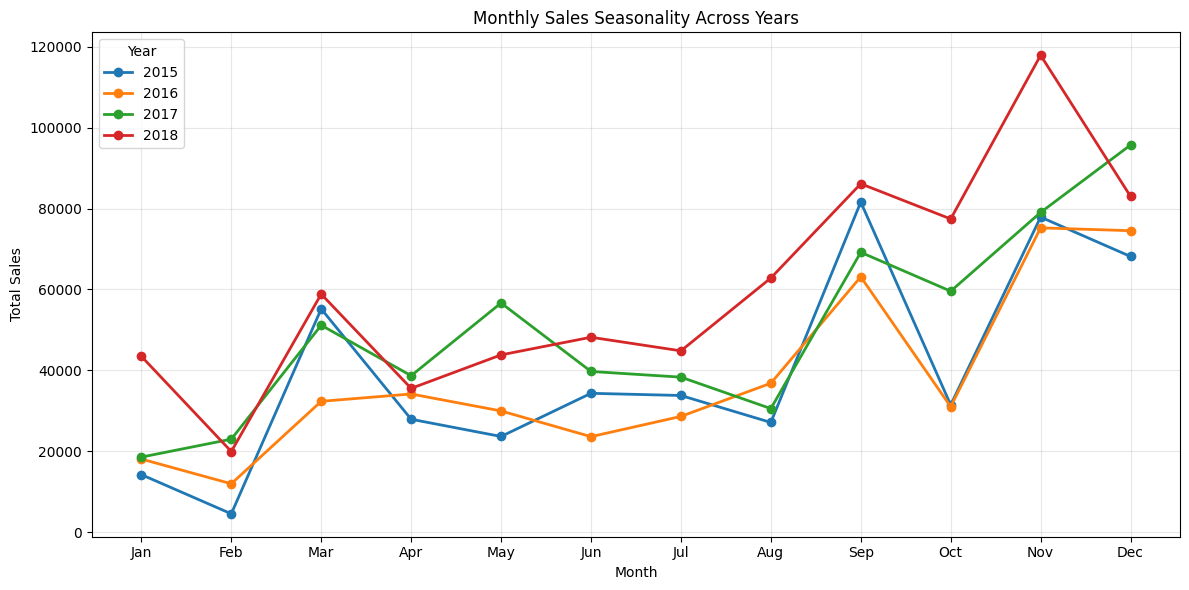

In [37]:
plt.figure(figsize=(12, 6))

for year in sorted(monthly_sales_pattern["Year"].unique()):
    
    year_data = monthly_sales_pattern[
        monthly_sales_pattern["Year"] == year
    ].sort_values("Month")

    plt.plot(
        year_data["Month"],
        year_data["Sales"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Sales Seasonality Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(
    range(1, 13),
    month_names
)

plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Finding 4: Monthly Sales Seasonality

The analysis shows a clear late-year seasonal pattern in sales. The September-to-December
period generally records stronger sales across the four years.

Based on average monthly total sales, November is the strongest month overall, followed
by December and September. However, no single month records the highest sales in every
year. The exact peak varies across years.

Therefore, the data indicates a broader late-year seasonal surge rather than an identical
spike in one specific month each year. This pattern may reflect year-end purchasing,
promotional campaigns, and holiday-season demand.

### TASK 2-> TIME SERIES ANALYSIS & DECOMPOSITION

In [38]:
# Overall monthly sales trend across all 4 years
monthly_sales = (df.set_index("Order Date").resample("MS")["Sales"].sum())

print("Number of Monthly Observations:", len(monthly_sales))
print("\nFirst 5 Months:")
display(monthly_sales.head())

print("\nLast 5 Months:")
display(monthly_sales.tail())

Number of Monthly Observations: 48

First 5 Months:


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64


Last 5 Months:


Order Date
2018-08-01     62837.8480
2018-09-01     86152.8880
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64

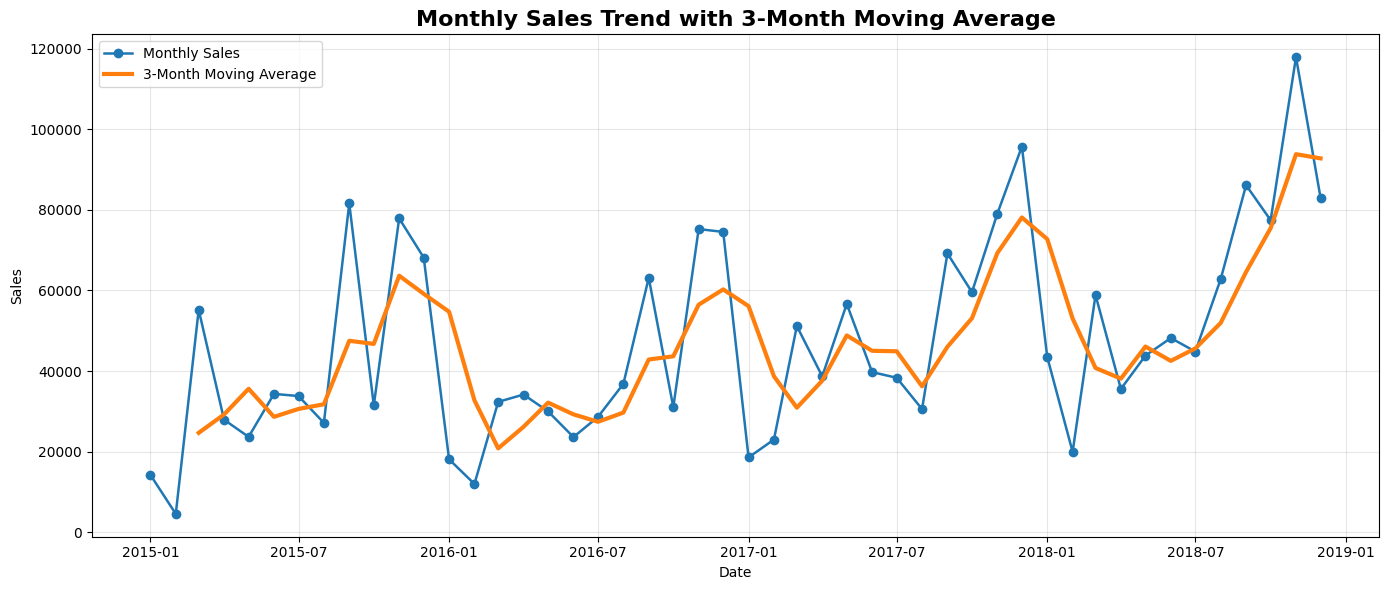

In [39]:
rolling_mean_3m = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index,monthly_sales.values,marker="o",linewidth=1.8,label="Monthly Sales")

plt.plot(rolling_mean_3m.index,rolling_mean_3m.values,linewidth=3,label="3-Month Moving Average")

plt.title("Monthly Sales Trend with 3-Month Moving Average",fontsize=16,fontweight="bold")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Monthly Sales Trend

The monthly sales series shows substantial month-to-month variation, indicating that sales 
are influenced by recurring seasonal effects and short-term fluctuations. Higher sales are 
frequently observed toward the later months of the year.
The 3-month moving average smooths short-term fluctuations and makes the underlying sales 
movement easier to interpret.

In [40]:
# Apply Time Series Decomposition 
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales,model="additive",period=12)

### Time Series Decomposition Method

An additive decomposition model was applied to the monthly sales series using a seasonal 
period of 12 months. A period of 12 is appropriate because the dataset is aggregated monthly, 
so one complete annual seasonal cycle contains 12 observations.

The additive decomposition separates observed sales into:

- **Trend:** the long-term direction of sales
- **Seasonal:** recurring patterns that repeat across years
- **Residual:** unexplained fluctuations remaining after trend and seasonality are removed

The additive formulation assumes:

**Observed Sales = Trend + Seasonal Component + Residual**

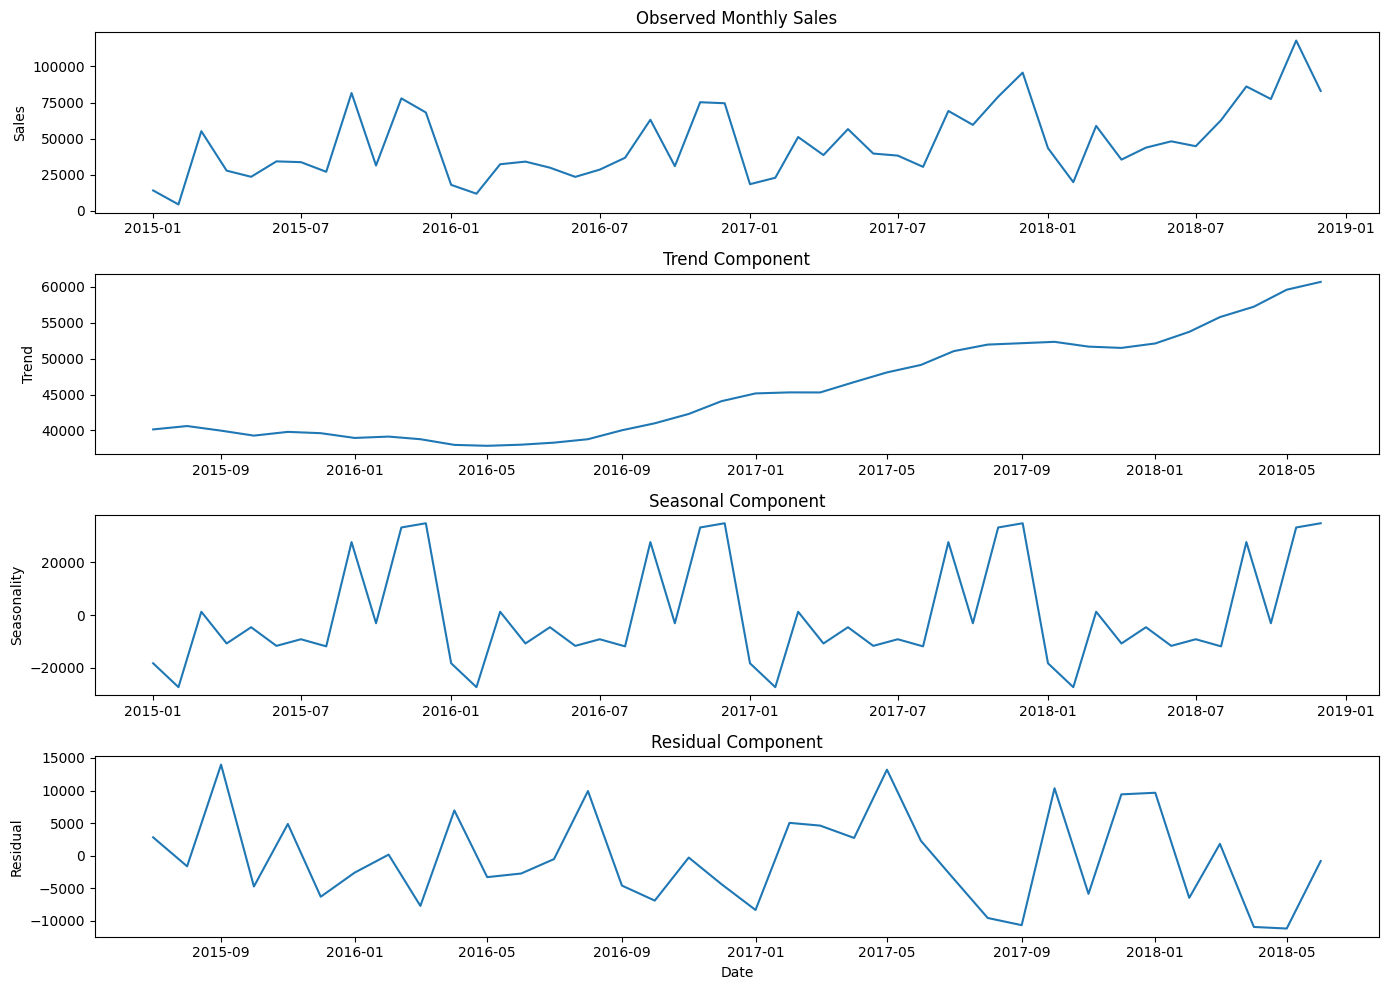

In [41]:
# Plot all 4 components clearly on one figure
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(decomposition.observed)
plt.title("Observed Monthly Sales")
plt.ylabel("Sales")

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend)
plt.title("Trend Component")
plt.ylabel("Trend")

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal)
plt.title("Seasonal Component")
plt.ylabel("Seasonality")

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid)
plt.title("Residual Component")
plt.ylabel("Residual")
plt.xlabel("Date")

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png",dpi=300,bbox_inches="tight")

plt.show()

#### Plot Explanation

The decomposition separates monthly sales into observed values, long-term trend, recurring seasonal pattern, and unexplained residual noise.

In [42]:
#Find months with highest residual noise
residuals = decomposition.resid.dropna()
highest_residuals = (residuals.abs().sort_values(ascending=False).head(5))
highest_residuals

Order Date
2015-09-01    13970.933082
2017-05-01    13193.079793
2018-05-01    11157.549320
2018-04-01    10916.959724
2017-09-01    10642.715643
Name: resid, dtype: float64

### Observations from Time Series Decomposition

**Question 1**->what does the trend tell you?

Answer-> The trend component shows that monthly sales generally increase over time. The trend rises more clearly from late 2016 onward and reaches its highest level in 2018, indicating overall business growth.

**Question 2**-> Is seasonality strong or weak? 

Answer-> The seasonal component shows a strong and repeating yearly pattern. Sales are generally higher toward the later months of the year, especially around September, November, and December, while the beginning of the year tends to have lower sales.

**Question 3**->What months show the highest residual noise?

Answer-> The residual component shows some large positive and negative fluctuations that are not explained by trend or seasonality. The highest residual noise is observed around September 2015, May 2017, September 2017, April 2018, and May 2018.

**Overall Explanation** ->The sales pattern is influenced by both long-term growth and yearly seasonality. However, some unusual monthly fluctuations remain, which may be caused by promotions, large orders, festive demand, or other temporary business events.

In [43]:
# Test for Stationarity using the Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.416136761430768
p-value: 0.00027791039276670677


### Stationarity and ADF Test

Stationarity means that the statistical behavior of a time series remains reasonably stable over time. This is important because many forecasting models perform better on stationary data.

The ADF test gave a p-value of approximately 0.000278, which is less than 0.05. Therefore, we reject the null hypothesis and conclude that the monthly sales series is stationary.

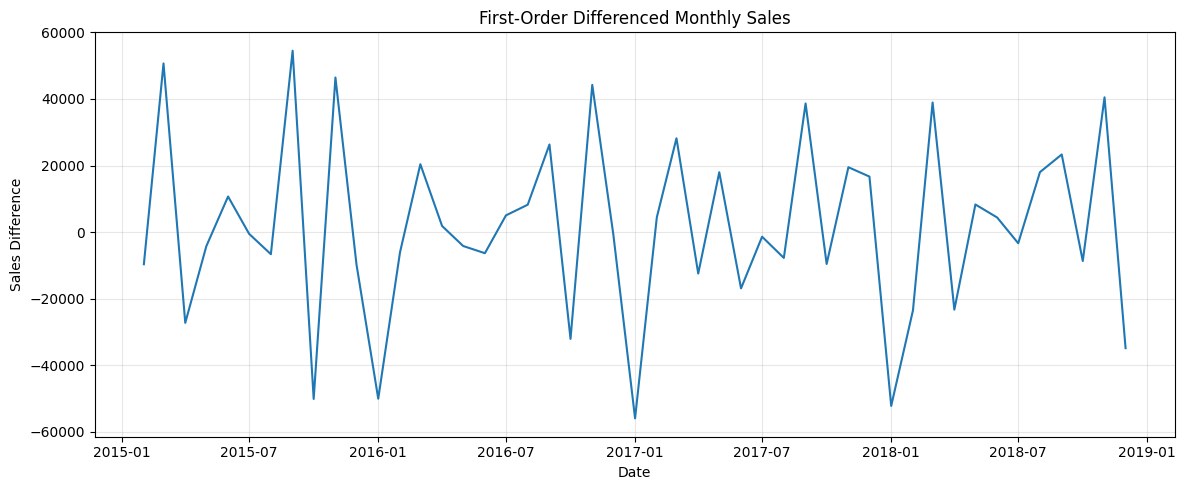

In [44]:
monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales_diff)

plt.title("First-Order Differenced Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales Difference")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/differenced_monthly_sales.png",dpi=300,bbox_inches="tight")

plt.show()

### Plot Explanation

The original series was already stationary, so differencing was not necessary. First-order differencing was applied only to compare the statistical behavior of the transformed series.

In [45]:
#Re-run the ADF test after the differenced series
adf_diff = adfuller(monthly_sales_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF Statistic: -8.72706183035328
p-value: 3.266917547279451e-14


In [46]:
adf_comparison = pd.DataFrame({
    "Series": [
        "Original Sales",
        "Differenced Sales"
    ],
    "ADF Statistic": [
        adf_result[0],
        adf_diff[0]
    ],
    "p-value": [
        adf_result[1],
        adf_diff[1]
    ]
})

adf_comparison

,Series,ADF Statistic,p-value
0,Original Sales,-4.416137,2.779104e-04
1,Differenced Sales,-8.727062,3.266918e-14


### TASK 3->SALES FORECASTING USING 3 DIFFERENT MODELS

In [47]:
# Prepare Train and Test Sets for Forecasting
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

print("Training Months:", len(train))
print("Testing Months:", len(test))

print("\nTest Data:")
print(test)

Training Months: 45
Testing Months: 3

Test Data:
Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64


### Train-Test Split

The monthly sales series was divided using a time-based split. The first 45 months were used for training and the last 3 months were kept for testing.

A random split was not used because time-series data must preserve chronological order.

In [48]:
#Model 1-> Sarima Model
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Fit the SARIMA model on the monthly sales data
sarima_model = SARIMAX(train,order=(1, 0, 1),seasonal_order=(1, 1, 0, 12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False,maxiter=500)

print("Model Converged:", sarima_result.mle_retvals["converged"])
print("AIC:", round(sarima_result.aic, 2))
print("BIC:", round(sarima_result.bic, 2))

Model Converged: True
AIC: 437.32
BIC: 441.3


### SARIMA Parameter Selection

The SARIMA model uses order (1, 0, 1) and seasonal order (1, 1, 0, 12).

- p = 1 captures short-term dependence on previous sales.
- d = 0 because the original monthly series was stationary.
- q = 1 captures short-term error patterns.
- D = 1 handles yearly seasonal differences.
- m = 12 represents annual seasonality in monthly data.

A simpler seasonal structure was selected because the dataset contains only 45 training observations and the more complex model showed convergence issues.

In [49]:
#Predict the 3 Test Months using the SARIMA model
sarima_pred = sarima_result.get_forecast(steps=3)

sarima_forecast = sarima_pred.predicted_mean
sarima_ci = sarima_pred.conf_int()

print("SARIMA Predictions:")
print(sarima_forecast)

SARIMA Predictions:
2018-10-01    58436.744529
2018-11-01    88180.984536
2018-12-01    97442.806645
Freq: MS, Name: predicted_mean, dtype: float64


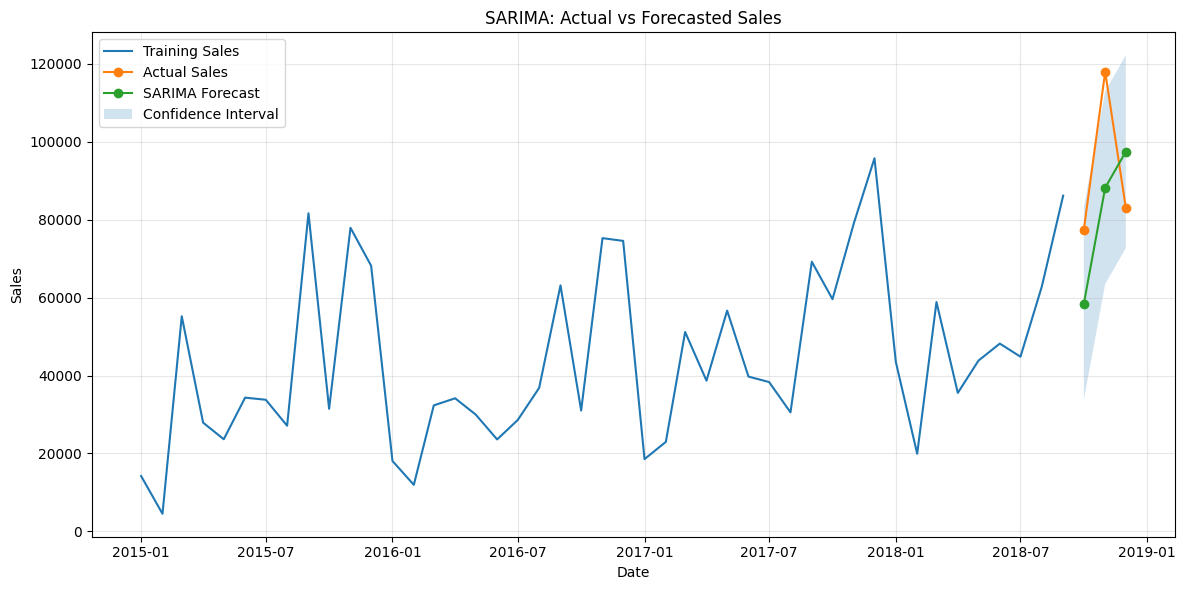

In [50]:
#Plot Actual vs forecasted values for the test months
plt.figure(figsize=(12, 6))

plt.plot(train.index,train,label="Training Sales")
plt.plot(test.index,test,marker="o",label="Actual Sales")
plt.plot(sarima_forecast.index,sarima_forecast,marker="o",label="SARIMA Forecast")
plt.fill_between(sarima_ci.index,sarima_ci.iloc[:, 0],sarima_ci.iloc[:, 1],alpha=0.2,label="Confidence Interval")

plt.title("SARIMA: Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("charts/sarima_actual_vs_forecast.png",dpi=300,bbox_inches="tight")
plt.show()

In [51]:
# Calaculate Metrics for SARIMA Model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test,sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test,sarima_forecast))
sarima_mape = np.mean(np.abs((test.values - sarima_forecast.values)/ test.values)) * 100

print("SARIMA MAE:", round(sarima_mae, 2))
print("SARIMA RMSE:", round(sarima_rmse, 2))
print("SARIMA MAPE:", round(sarima_mape, 2), "%")

SARIMA MAE: 21060.32
SARIMA RMSE: 22019.99
SARIMA MAPE: 22.38 %


### SARIMA Evaluation

The SARIMA model was evaluated on the final 3 months using MAE, RMSE, and MAPE.

Lower values indicate better forecasting performance. These results will later be compared with Prophet and XGBoost using the same test period.

In [52]:
#Generate the Required Future 3-month Forecast using the SARIMA model
sarima_final_model = SARIMAX(monthly_sales,order=(1, 0, 1),seasonal_order=(1, 1, 1, 12))
sarima_final_result = sarima_final_model.fit(disp=False)
sarima_future = sarima_final_result.get_forecast(steps=3)
sarima_future_forecast = (sarima_future.predicted_mean)
sarima_future_ci = (sarima_future.conf_int())

print("Next 3-Month SARIMA Forecast:")
print(sarima_future_forecast)

print("\nConfidence Intervals:")
print(sarima_future_ci)

/opt/anaconda3/envs/mac_flowers/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/mac_flowers/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/envs/mac_flowers/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Next 3-Month SARIMA Forecast:
2019-01-01    48057.446376
2019-02-01    34177.552612
2019-03-01    68799.532637
Freq: MS, Name: predicted_mean, dtype: float64

Confidence Intervals:
             lower Sales   upper Sales
2019-01-01  21353.107020  74761.785732
2019-02-01   7473.009580  60882.095643
2019-03-01  42094.786001  95504.279274


In [53]:
#Model 2-> Prophet Model
!pip install prophet

In [54]:
from prophet import Prophet

#Prepare the data for Prophet model
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ["ds", "y"]
prophet_df.head()

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [55]:
# Train-Test Split for Prophet Model
prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

print("Training Months:", len(prophet_train))
print("Testing Months:", len(prophet_test))

Training Months: 45
Testing Months: 3


In [56]:
#Train the Prophet model on the training data
prophet_model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
prophet_model.fit(prophet_train)

00:59:53 - cmdstanpy - INFO - Chain [1] start processing
00:59:54 - cmdstanpy - INFO - Chain [1] done processing


### Prophet Model

Yearly seasonality was enabled because the monthly sales data shows a recurring annual pattern. Weekly and daily seasonality were disabled because the data is aggregated at monthly level.

In [57]:
#Predict the 3 Test Months using the Prophet model
future_test = prophet_model.make_future_dataframe(periods=3,freq="MS")
prophet_pred = prophet_model.predict(future_test)
prophet_forecast = prophet_pred[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)
prophet_forecast

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-01,51083.663790,43438.223072,58562.242193
46,2018-11-01,90045.402141,82584.808896,98206.411627
47,2018-12-01,89661.190745,81473.190764,97400.401224


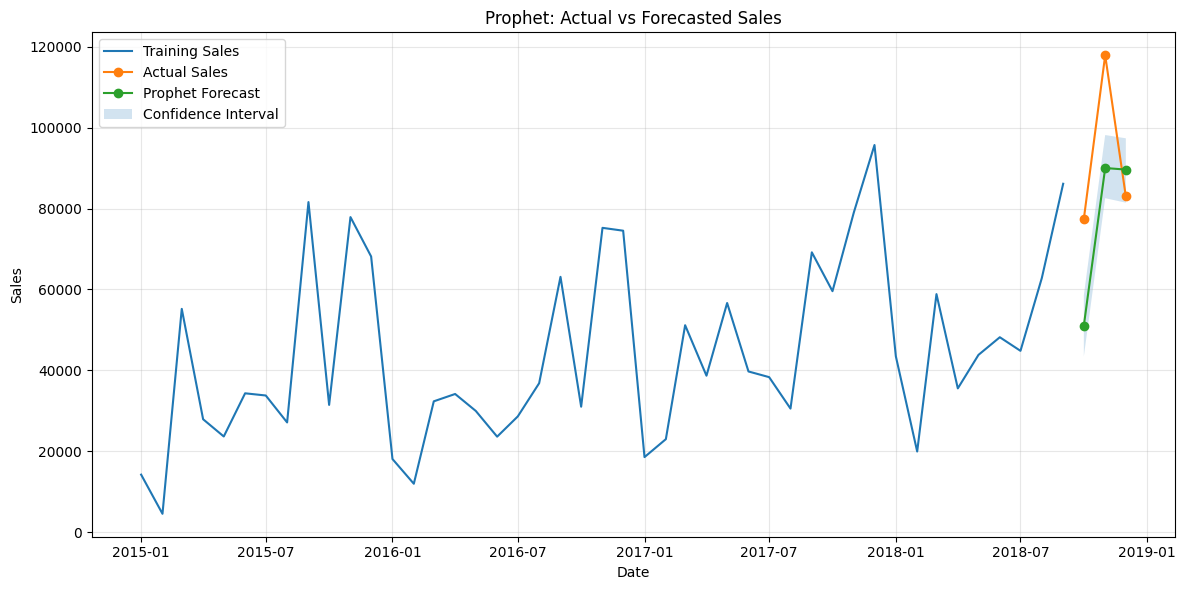

In [58]:
#Plot Actual vs Predicted Sales for the Test Months
plt.figure(figsize=(12, 6))

plt.plot(prophet_train["ds"],prophet_train["y"],label="Training Sales")
plt.plot(prophet_test["ds"],prophet_test["y"],marker="o",label="Actual Sales")
plt.plot(prophet_forecast["ds"],prophet_forecast["yhat"],marker="o",label="Prophet Forecast")

plt.fill_between(prophet_forecast["ds"],prophet_forecast["yhat_lower"],prophet_forecast["yhat_upper"],alpha=0.2,label="Confidence Interval")

plt.title("Prophet: Actual vs Forecasted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/prophet_actual_vs_forecast.png",dpi=300,bbox_inches="tight")

plt.show()

In [59]:
#Calaculate Metrics for Prophet Model
prophet_mae = mean_absolute_error(prophet_test["y"],prophet_forecast["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test["y"],prophet_forecast["yhat"]))
prophet_mape = np.mean(np.abs((prophet_test["y"].values- prophet_forecast["yhat"].values)/ prophet_test["y"].values)) * 100

print("Prophet MAE:", round(prophet_mae, 2))
print("Prophet RMSE:", round(prophet_rmse, 2))
print("Prophet MAPE:", round(prophet_mape, 2), "%")

Prophet MAE: 20296.01
Prophet RMSE: 22487.47
Prophet MAPE: 21.89 %


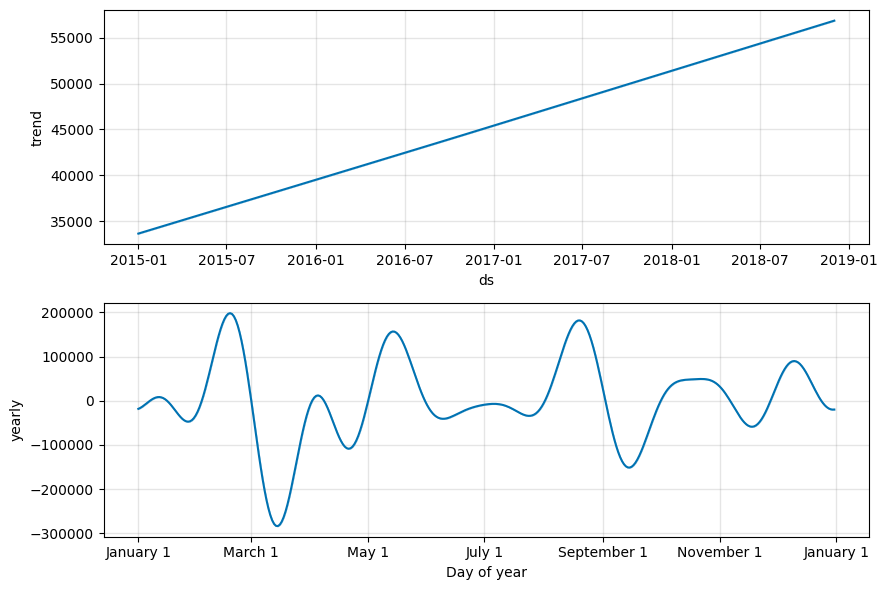

In [60]:
#Plot Prophet Trend and Seasonality Components
fig = prophet_model.plot_components(prophet_pred)
plt.savefig("charts/prophet_components.png",dpi=300,bbox_inches="tight")
plt.show()

### Prophet Seasonality Interpretation

The trend component shows the long-term direction of sales over time. The yearly seasonality component shows recurring changes in sales across different months of the year.

Weekly seasonality was not interpreted because the forecasting series is aggregated monthly, so weekly patterns cannot be reliably estimated from this data.

In [61]:
#Generate the Required Future 3-month Forecast using the Prophet model
prophet_final = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)
prophet_final.fit(prophet_df)

future = prophet_final.make_future_dataframe(periods=3,freq="MS")
future_forecast = prophet_final.predict(future)
prophet_future = future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

print("Next 3-Month Prophet Forecast:")
prophet_future

00:59:55 - cmdstanpy - INFO - Chain [1] start processing
00:59:55 - cmdstanpy - INFO - Chain [1] done processing


Next 3-Month Prophet Forecast:


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-01,42548.142576,33262.020729,50985.499509
49,2019-02-01,33310.125087,23659.002838,42743.868516
50,2019-03-01,80304.673390,70866.579669,89737.512053


In [62]:
# Model 3-> XGBoost Model
!pip install xgboost

In [63]:
from xgboost import XGBRegressor

#Prepare Monthly Sales Data for XGBoost Model
xgb_df = monthly_sales.reset_index()
xgb_df.columns = ["Date", "Sales"]
xgb_df.head()

,Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [64]:
#Create Lag and Time features for XGBoost Model
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean_3"] = (xgb_df["Sales"].shift(1).rolling(3).mean())
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 4

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

xgb_df = xgb_df.dropna().reset_index(drop=True)
xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
0,2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,2
1,2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,2
2,2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,3
3,2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,3
4,2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,3


### XGBoost Feature Engineering

The monthly time series was converted into a supervised machine learning dataset. Lag features represent sales from the previous 1, 2, and 3 months.

A 3-month rolling mean was added to capture recent sales behavior. Month, quarter, and season were included to represent calendar-based patterns.

In [65]:
#Select Features and Target Variable for XGBoost Model
features = ["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]
X = xgb_df[features]
y = xgb_df["Sales"]

In [66]:
#Train - Test Split for XGBoost Model
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 42
Testing Samples: 3


In [67]:
#Train the XGBoost model on the training data
xgb_model = XGBRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=42)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### XGBoost Model

The XGBoost Regressor was trained using lag features, rolling average, and calendar-based features. The model learns non-linear relationships between recent sales patterns and future monthly demand.

In [68]:
#Predict the 3 Test Months using the XGBoost model
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Predictions:")
print(xgb_pred)

XGBoost Predictions:
[68952.87 87130.1  66202.34]


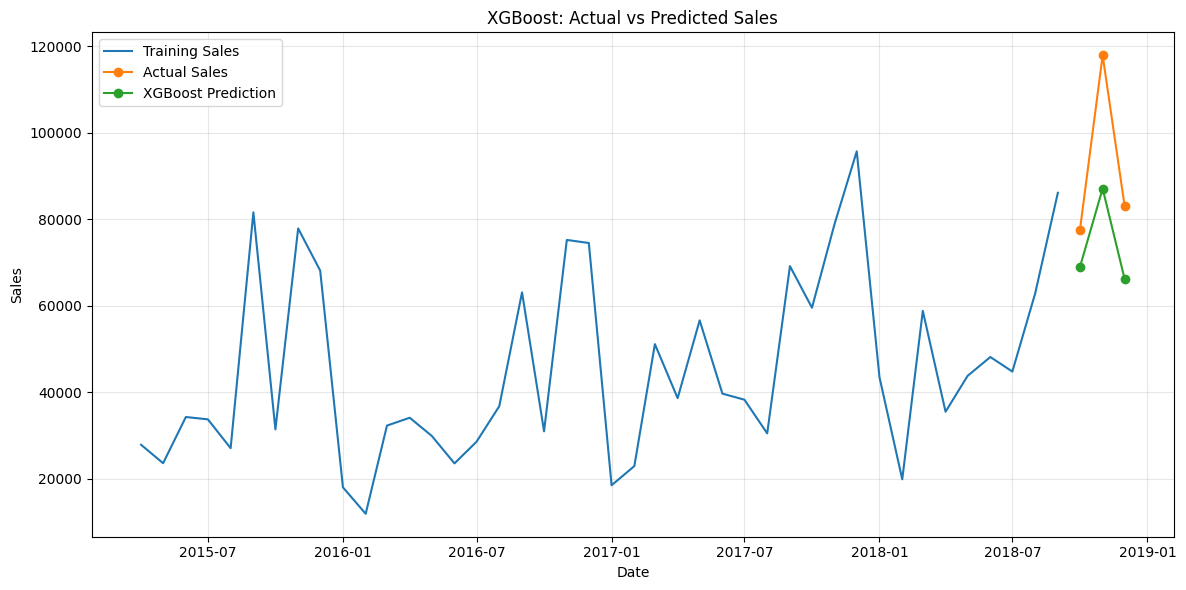

In [69]:
#Plot Actual vs Predicted Sales 
plt.figure(figsize=(12, 6))

plt.plot(xgb_df["Date"].iloc[:-3],y_train,label="Training Sales")
plt.plot(xgb_df["Date"].iloc[-3:],y_test,marker="o",label="Actual Sales")
plt.plot(xgb_df["Date"].iloc[-3:],xgb_pred,marker="o",label="XGBoost Prediction")

plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/xgboost_actual_vs_predicted.png",dpi=300,bbox_inches="tight")

plt.show()

In [70]:
#Calculate Metrics for XGBoost Model
xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test,xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred)/ y_test.values)) * 100

print("XGBoost MAE:", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))
print("XGBoost MAPE:", round(xgb_mape, 2), "%")

XGBoost MAE: 18710.45
XGBoost RMSE: 20852.57
XGBoost MAPE: 19.12 %


In [71]:
#Predict the Actual Future Next 3-Month Sales using the XGBoost model
xgb_final = XGBRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=42)
xgb_final.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [72]:
future_predictions = []
sales_history = monthly_sales.tolist()
last_date = monthly_sales.index[-1]
for i in range(1, 4):
    future_date = last_date + pd.DateOffset(months=i)
    lag_1 = sales_history[-1]
    lag_2 = sales_history[-2]
    lag_3 = sales_history[-3]
    rolling_mean = np.mean(sales_history[-3:])

    month = future_date.month
    quarter = future_date.quarter
    season = get_season(month)

    future_data = pd.DataFrame({"Lag_1": [lag_1],"Lag_2": [lag_2],"Lag_3": [lag_3],"Rolling_Mean_3": [rolling_mean],"Month": [month],"Quarter": [quarter],"Season": [season]})
    prediction = xgb_final.predict(future_data)[0]
    future_predictions.append({"Date": future_date,"Forecast": prediction})
    sales_history.append(prediction)

xgb_future = pd.DataFrame(future_predictions)
xgb_future

,Date,Forecast
0,2019-01-01,44980.054688
1,2019-02-01,25957.798828
2,2019-03-01,54965.558594


### Recursive Future Forecasting

The next 3 months were predicted recursively. After each monthly forecast, the predicted value was added to the sales history and used as a lag feature for forecasting the following month.

In [73]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        sarima_future_forecast.iloc[0],
        prophet_future["yhat"].iloc[0],
        xgb_future["Forecast"].iloc[0]
    ],

    "Forecast Month 2": [
        sarima_future_forecast.iloc[1],
        prophet_future["yhat"].iloc[1],
        xgb_future["Forecast"].iloc[1]
    ],

    "Forecast Month 3": [
        sarima_future_forecast.iloc[2],
        prophet_future["yhat"].iloc[2],
        xgb_future["Forecast"].iloc[2]
    ]
})

comparison.round(2)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,21060.32,22019.99,22.38,48057.45,34177.55,68799.53
1,Prophet,20296.01,22487.47,21.89,42548.14,33310.13,80304.67
2,XGBoost,18710.45,20852.57,19.12,44980.05,25957.80,54965.56


#### Which Model we would recommend for production use and why?

XGBoost achieved the best overall forecasting performance with the lowest MAE of 18,710.45, RMSE of 20,852.57, and MAPE of 19.12%.

Prophet achieved a MAPE of 21.89%, while SARIMA recorded 22.38%. Since lower error values indicate better forecasting performance, XGBoost performed best across all three evaluation metrics.

Therefore, XGBoost is selected as the best-performing model for this project and will be used for the category-level and region-level forecasting in Task 4.

### TASK 4-> PRODUCT CATEGORY & REGIONAL LEVEL FORECASTING

In [74]:
# Create Forecasting function
def forecast_segment(data, months=3):

    monthly = (
        data.set_index("Order Date")
        .resample("MS")["Sales"]
        .sum()
    )

    temp = monthly.reset_index()
    temp.columns = ["Date", "Sales"]

    temp["Lag_1"] = temp["Sales"].shift(1)
    temp["Lag_2"] = temp["Sales"].shift(2)
    temp["Lag_3"] = temp["Sales"].shift(3)

    temp["Rolling_Mean_3"] = (
        temp["Sales"].shift(1).rolling(3).mean()
    )

    temp["Month"] = temp["Date"].dt.month
    temp["Quarter"] = temp["Date"].dt.quarter
    temp["Season"] = temp["Month"].apply(get_season)

    temp = temp.dropna()

    X = temp[features]
    y = temp["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X, y)

    sales_history = monthly.tolist()
    last_date = monthly.index[-1]
    predictions = []

    for i in range(1, months + 1):

        future_date = last_date + pd.DateOffset(months=i)

        future_data = pd.DataFrame({
            "Lag_1": [sales_history[-1]],
            "Lag_2": [sales_history[-2]],
            "Lag_3": [sales_history[-3]],
            "Rolling_Mean_3": [np.mean(sales_history[-3:])],
            "Month": [future_date.month],
            "Quarter": [future_date.quarter],
            "Season": [get_season(future_date.month)]
        })

        pred = model.predict(future_data)[0]

        predictions.append(pred)
        sales_history.append(pred)

    return predictions

### Segment-Level Forecasting

XGBoost was selected because it achieved the lowest MAE, RMSE, and MAPE in Task 3. The same forecasting approach was applied separately to each required product category and region.

In [75]:
# Create category datasets
furniture_df = df[df["Category"] == "Furniture"]
technology_df = df[df["Category"] == "Technology"]
office_df = df[df["Category"] == "Office Supplies"]

# create Region datasets
west_df = df[df["Region"] == "West"]
east_df = df[df["Region"] == "East"]

In [76]:
#Generate all 5 forecasts using the forecast_segment function
furniture_forecast = forecast_segment(furniture_df)
technology_forecast = forecast_segment(technology_df)
office_forecast = forecast_segment(office_df)

west_forecast = forecast_segment(west_df)
east_forecast = forecast_segment(east_df)

In [77]:
#Create Forecast table
future_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

segment_forecasts = pd.DataFrame({
    "Date": future_dates,
    "Furniture": furniture_forecast,
    "Technology": technology_forecast,
    "Office Supplies": office_forecast,
    "West": west_forecast,
    "East": east_forecast
})

segment_forecasts.round(2)

segment_forecasts.to_csv("charts/segment_forecasts.csv",index=False)

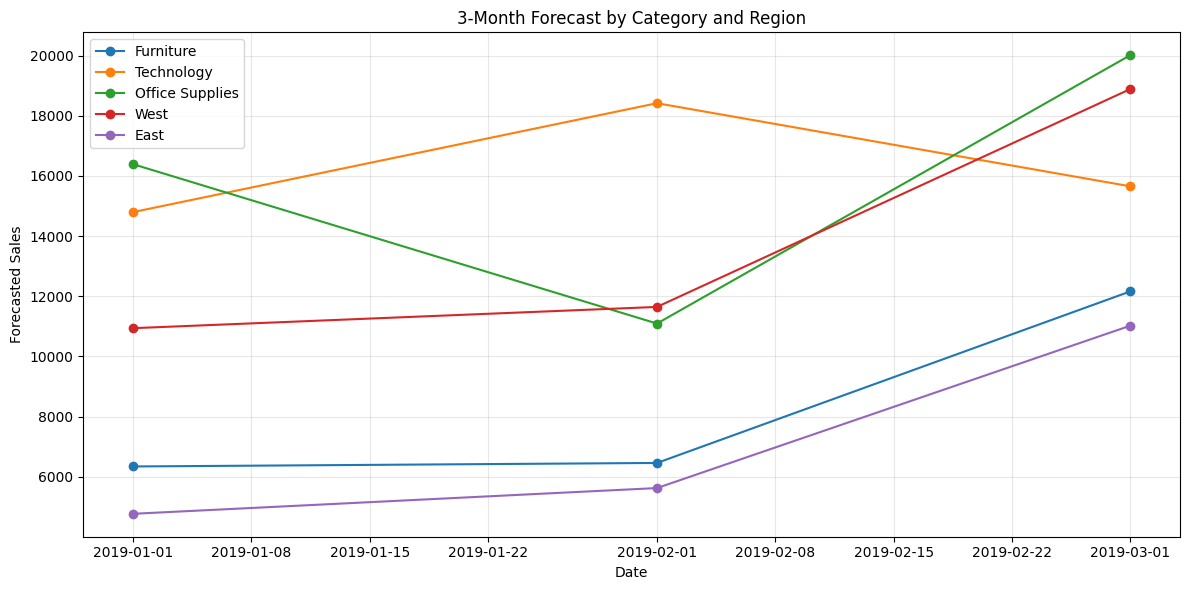

In [78]:
# Plot all 5 forecasts 
plt.figure(figsize=(12, 6))

plt.plot(
    future_dates,
    furniture_forecast,
    marker="o",
    label="Furniture"
)

plt.plot(
    future_dates,
    technology_forecast,
    marker="o",
    label="Technology"
)

plt.plot(
    future_dates,
    office_forecast,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    future_dates,
    west_forecast,
    marker="o",
    label="West"
)

plt.plot(
    future_dates,
    east_forecast,
    marker="o",
    label="East"
)

plt.title("3-Month Forecast by Category and Region")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/segment_forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
growth = {}

for col in segment_forecasts.columns[1:]:

    first = segment_forecasts[col].iloc[0]
    last = segment_forecasts[col].iloc[-1]

    growth[col] = ((last - first) / first) * 100

growth_df = pd.DataFrame({
    "Segment": growth.keys(),
    "Growth (%)": growth.values()
})

growth_df = growth_df.sort_values("Growth (%)",ascending=False)

growth_df.round(2)

strongest_segment = growth_df.iloc[0]

print("Strongest Upcoming Growth:",strongest_segment["Segment"])
print("Growth Rate:",round(strongest_segment["Growth (%)"], 2),"%")

Strongest Upcoming Growth: East
Growth Rate: 131.11 %


#### Question-> Which category/region is showing the strongest upcoming growth according to your model?

According to the XGBoost forecasts, the **East region** shows the strongest upcoming growth, with a projected growth rate of approximately **131.11%** from the first forecast month to the third forecast month.

Sales in the East region are forecasted to increase from approximately **4,768.17 in January 2019** to **11,019.61 in March 2019**. This suggests a strong upward demand pattern and indicates that the business should consider increasing inventory availability and stock allocation in the East region.


### TASK 5-> ANOMALY DETECTION IN SALES DATA

In [80]:
# Check weekly Sales data
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Weekly Sales Data

Sales were aggregated at the weekly level because weekly data provides enough detail to identify unusual short-term spikes and drops while reducing daily fluctuations.

In [81]:
# Use Isolation Forest  to detect anomalous sales weeks 
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.05,random_state=42)
weekly_sales["IF_Anomaly"] = iso_model.fit_predict(weekly_sales[["Sales"]])
if_anomalies = weekly_sales[weekly_sales["IF_Anomaly"] == -1]

if_anomalies

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


### Isolation Forest

Isolation Forest was used to detect unusual sales weeks. The contamination value was set to 0.05, meaning approximately 5% of the weeks were expected to be unusual.

Weeks labelled as -1 are treated as anomalies, while weeks labelled as 1 are considered normal.

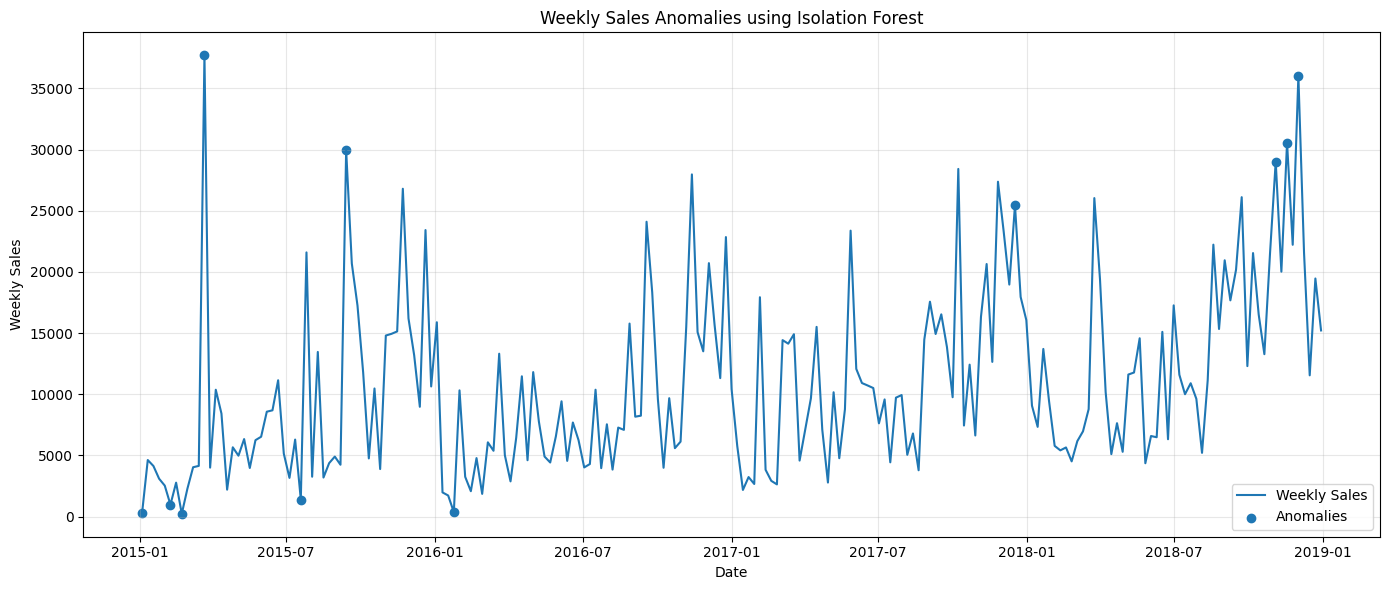

In [82]:
#Plot Isolation Forest Anomalies
plt.figure(figsize=(14, 6))

plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"],label="Weekly Sales")
plt.scatter(if_anomalies["Order Date"],if_anomalies["Sales"],marker="o",label="Anomalies")

plt.title("Weekly Sales Anomalies using Isolation Forest")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/isolation_forest_anomalies.png",dpi=300,bbox_inches="tight")
plt.show()

In [83]:
if_anomalies[["Order Date", "Sales"]].sort_values("Order Date")
median_sales = weekly_sales["Sales"].median()

if_anomalies = if_anomalies.copy()
if_anomalies["Possible Explanation"] = np.where(if_anomalies["Sales"] > median_sales,"Possible promotion, festive demand, or large orders","Possible low demand, stock shortage, or seasonal slowdown")
if_anomalies[["Order Date", "Sales", "Possible Explanation"]]
if_anomalies[["Order Date", "Sales", "Possible Explanation"]].to_csv("charts/isolation_forest_anomalies.csv",index=False)

#### Question -> A possible real-world explanation for each detected anomaly?
- High-sales anomalies may result from promotional campaigns, festive demand, seasonal shopping periods, or unusually large customer orders.
- Low-sales anomalies may result from temporary stock shortages, weak seasonal demand, fewer orders, or operational disruptions.
- The high-sales anomalies detected in November and December 2018 may reflect year-end shopping demand, although the exact cause cannot be confirmed from the available dataset.

In [84]:
# Applying a second anomaly detection method: Z-Score based detection
weekly_sales["Rolling_Mean"] = (weekly_sales["Sales"].rolling(window=12).mean())
weekly_sales["Rolling_Std"] = (weekly_sales["Sales"].rolling(window=12).std())

weekly_sales["Z_Score"] = (weekly_sales["Sales"]- weekly_sales["Rolling_Mean"]) / weekly_sales["Rolling_Std"]
weekly_sales["Z_Anomaly"] = (weekly_sales["Z_Score"].abs() > 2)

z_anomalies = weekly_sales[weekly_sales["Z_Anomaly"]]
z_anomalies[["Order Date", "Sales", "Z_Score"]]
z_anomalies[["Order Date", "Sales", "Z_Score"]].to_csv("charts/z_score_anomalies.csv",index=False)

### Z-Score Based Detection

A rolling Z-score method was used as the second anomaly detection technique. The rolling mean and standard deviation were calculated over a 12-week window.

A week was flagged as anomalous when its sales value deviated by more than 2 standard deviations from the rolling mean.

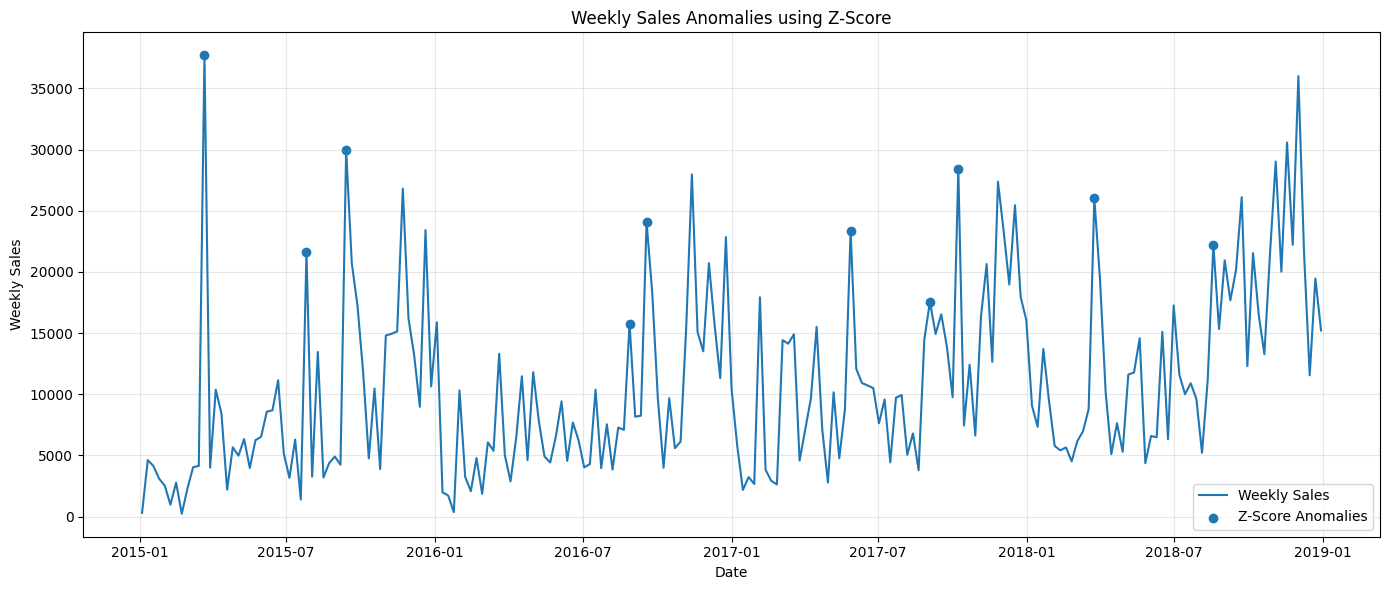

In [85]:
#Plot Z-Score Anomalies
plt.figure(figsize=(14, 6))

plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"],label="Weekly Sales")
plt.scatter(z_anomalies["Order Date"],z_anomalies["Sales"],marker="o",label="Z-Score Anomalies")

plt.title("Weekly Sales Anomalies using Z-Score")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/zscore_anomalies.png",dpi=300,bbox_inches="tight")

plt.show()

In [86]:
#Compare Both Anaomaly Detection Methods
if_dates = set(if_anomalies["Order Date"])
z_dates = set(z_anomalies["Order Date"])
common_dates = if_dates.intersection(z_dates)

print("Isolation Forest Anomalies:",len(if_dates))
print("Z-Score Anomalies:",len(z_dates))
print("Common Anomalies:",len(common_dates))

common_anomalies = weekly_sales[weekly_sales["Order Date"].isin(common_dates)][["Order Date", "Sales"]]
common_anomalies

common_anomalies.to_csv("charts/common_anomalies.csv",index=False)


Isolation Forest Anomalies: 11
Z-Score Anomalies: 10
Common Anomalies: 2


#### Question-> Do both methods flag the same anomalies, or do they disagree? What does this tell us?

The two anomaly detection methods mostly **disagree**. Isolation Forest detected **11 anomalous weeks**, while the Z-Score method detected **10 anomalous weeks**. Only **2 weeks** were flagged by both methods:

- **22 March 2015** with weekly sales of approximately **37,703.67**
- **13 September 2015** with weekly sales of approximately **29,959.14**

This shows that the two methods identify anomalies differently. Isolation Forest detects unusual observations based on the overall sales distribution and flagged both unusually high and unusually low sales weeks. In contrast, the rolling Z-Score method detects weeks that differ strongly from their recent 12-week sales pattern.

The two common anomalies provide stronger evidence of genuinely unusual sales spikes because both methods independently identified them. The disagreement also shows that anomaly detection depends on the method used, so combining multiple techniques gives a more complete view of unusual sales behavior.

### TASK 6-> PRODUCT DEMAND SEGMENTATION USING CLUSTERING

In [87]:
#Calculate the total sales and average order value
product_features = df.groupby("Sub-Category").agg(Total_Sales=("Sales", "sum"),Average_Order_Value=("Sales", "mean")).reset_index()
product_features.head()

,Sub-Category,Total_Sales,Average_Order_Value
0,Accessories,164186.7000,217.178175
1,Appliances,104618.4030,227.926804
2,Art,26705.4100,34.019631
3,Binders,200028.7850,134.067550
4,Bookcases,113813.1987,503.598224


### Product Demand Features

Product demand was analyzed at the sub-category level. Total sales measures overall demand volume, while average order value represents the average sales value of transactions within each sub-category.

In [88]:
#Calculate Sales Volatility
monthly_subcat = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="MS")
    ])["Sales"]
    .sum()
    .reset_index()
)

volatility = (monthly_subcat.groupby("Sub-Category")["Sales"].std().reset_index(name="Sales_Volatility"))

#Calculate year Over Year Growth
yearly_subcat = (df.groupby(["Sub-Category", "Year"])["Sales"].sum().reset_index())
yearly_subcat["YoY_Growth"] = (yearly_subcat.groupby("Sub-Category")["Sales"].pct_change(fill_method=None) * 100)
growth_rate = (yearly_subcat.groupby("Sub-Category")["YoY_Growth"].mean().reset_index(name="Growth_Rate"))
growth_rate

,Sub-Category,Growth_Rate
0,Accessories,37.638071
1,Appliances,39.927584
2,Art,16.605553
3,Binders,21.873607
4,Bookcases,23.806516
5,Chairs,7.135790
6,Copiers,84.671819
7,Envelopes,-2.766643
8,Fasteners,15.703383
9,Furnishings,28.788938


In [89]:
#Merge All Features 
product_features = product_features.merge(volatility,on="Sub-Category")
product_features = product_features.merge(growth_rate,on="Sub-Category")

product_features = product_features.fillna(0)

product_features.head()
product_features.to_csv("charts/product_demand_features.csv",index=False)

In [90]:
#Check Missing values 
product_features.isnull().sum()
product_features = product_features.fillna(0)

Four demand features were created for each product sub-category:

- **Total Sales:** overall sales volume
- **Growth Rate:** average year-over-year sales growth
- **Sales Volatility:** variation in monthly sales
- **Average Order Value:** average transaction sales value

These features represent the size, growth, stability, and value of product demand.

In [91]:
# Standarize the features for clustering
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Total_Sales",
    "Growth_Rate",
    "Sales_Volatility",
    "Average_Order_Value"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(product_features[cluster_features])

### Feature Scaling

The clustering features have different numerical ranges. For example, total sales is much larger in scale than growth rate.

StandardScaler was applied so that each feature contributes fairly to the K-Means clustering process.

In [92]:
#Using the elbow method to determine the optimal number of clusters
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 9):

    model = KMeans(n_clusters=k,random_state=42,n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

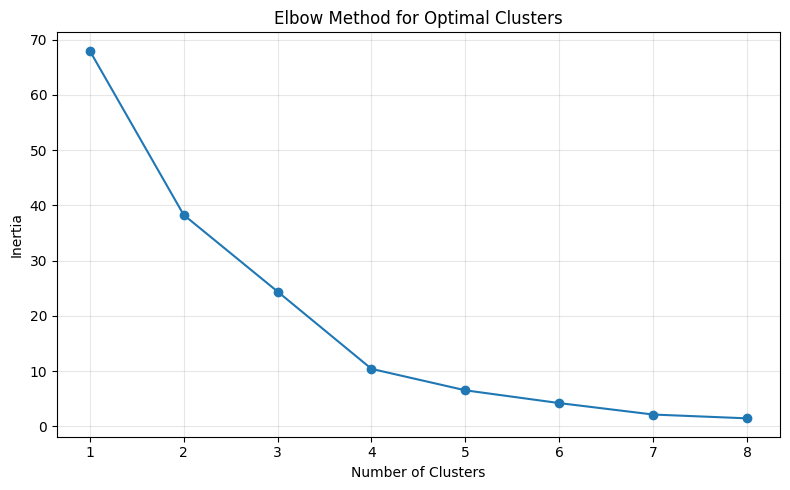

In [93]:
#Plotting the elbow curve
plt.figure(figsize=(8, 5))

plt.plot(range(1, 9),inertia,marker="o")

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/elbow_method.png",dpi=300,bbox_inches="tight")

plt.show()

### Elbow Method Result

The Elbow Method was used to select the number of clusters. The graph shows a large reduction in inertia from K = 1 to K = 4. After K = 4, the reduction becomes much smaller.

Therefore, **4 clusters** were selected as a reasonable number of product demand segments.

In [94]:
#Apply KMeans Clustering with the optimal number of clusters (k=4)
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
product_features["Cluster"] = (kmeans.fit_predict(X_scaled))
cluster_summary = (product_features.groupby("Cluster")[cluster_features].mean().round(2))
cluster_summary

,Total_Sales,Growth_Rate,Sales_Volatility,Average_Order_Value
Cluster,,,,
0,167743.36,46.34,5552.16,1930.72
1,55331.88,19.96,907.22,129.05
2,239495.78,18.10,3489.06,361.13
3,46420.31,192.84,2025.09,252.28


### K-Means Clustering

K-Means clustering was applied with K = 4 based on the Elbow Method. The algorithm grouped product sub-categories according to similarities in total sales, growth rate, sales volatility, and average order value.

The cluster averages were then analyzed to assign meaningful business labels to each demand segment.

### Product Demand Segment Findings

The K-Means model identified four distinct product demand segments:

- **Cluster 0 — High Value, Volatile Demand:** This cluster has high average order value and the highest sales volatility. It also shows strong growth, indicating valuable but less predictable demand.

- **Cluster 1 — Low Volume, Stable Demand:** This cluster has relatively low total sales, low average order value, and the lowest sales volatility. Demand is more stable but limited in volume.

- **Cluster 2 — High Volume, Established Demand:** This cluster generates the highest total sales, with moderate volatility and positive growth. It represents the strongest established demand group.

- **Cluster 3 — Rapidly Growing Demand:** This cluster has lower current sales volume but an exceptionally high average growth rate of approximately 192.84%. It represents emerging product demand with strong future potential.

In [95]:
cluster_labels = {
    0: "High Value, Volatile Demand",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Established Demand",
    3: "Rapidly Growing Demand"
}

product_features["Demand_Segment"] = (product_features["Cluster"].map(cluster_labels))
product_features[
    [
        "Sub-Category",
        "Cluster",
        "Demand_Segment"
    ]
].sort_values("Cluster")

product_features.to_csv("charts/product_clusters.csv",index=False)


In [96]:
#Apply PCA for 2D Visualization of Clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

product_features["PCA1"] = pca_result[:, 0]
product_features["PCA2"] = pca_result[:, 1]

### PCA Visualization

PCA was used to reduce the four clustering features into two dimensions for visualization. The PCA components summarize the main variation in the original features.

The scatter plot shows how product sub-categories are separated into four demand groups based on their overall sales behavior.

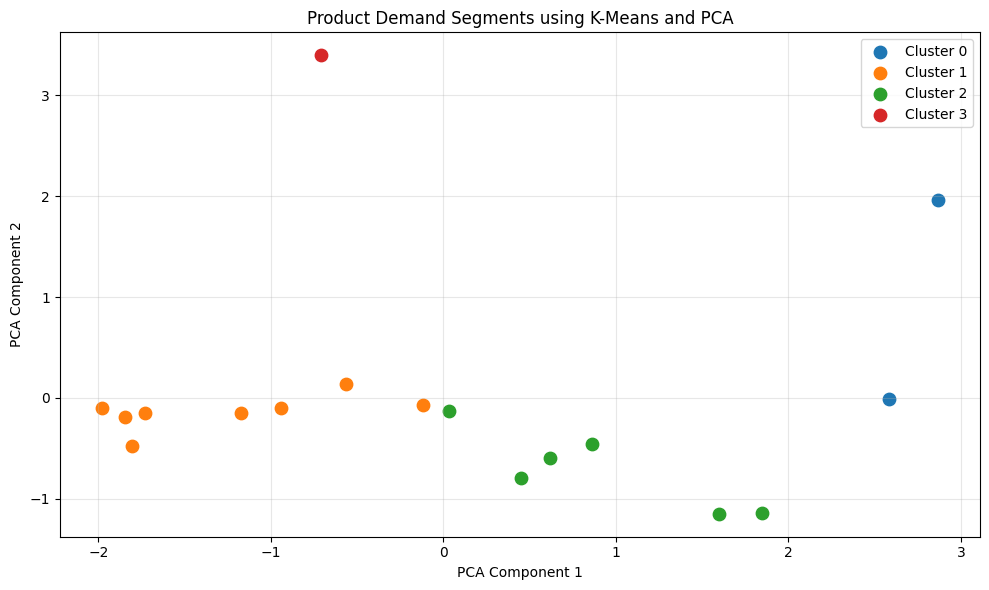

In [97]:
#Plot Cluster
plt.figure(figsize=(10, 6))

for cluster in sorted(product_features["Cluster"].unique()):

    data = product_features[product_features["Cluster"] == cluster]
    plt.scatter(data["PCA1"],data["PCA2"],label=f"Cluster {cluster}",s=80)

plt.title("Product Demand Segments using K-Means and PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/product_demand_clusters.png",dpi=300,bbox_inches="tight")

plt.show()

In [98]:
#Display Sub categories for cluster
product_features[
    [
        "Sub-Category",
        "Cluster",
        "Total_Sales",
        "Growth_Rate",
        "Sales_Volatility",
        "Average_Order_Value"
    ]
].sort_values("Cluster")

product_features.to_csv("charts/product_clusters.csv",index=False)

#### Question-> What stocking strategy would you recommend for each cluster?

- **Cluster 0 — High Value, Volatile Demand:** Maintain moderate safety stock and use frequent demand monitoring. Since these products have high value and high volatility, excessive inventory could increase holding costs.

- **Cluster 1 — Low Volume, Stable Demand:** Keep lean inventory with regular replenishment. The low volatility makes demand more predictable, so large safety stocks are not necessary.

- **Cluster 2 — High Volume, Established Demand:** Maintain high product availability and sufficient safety stock. Since this cluster generates the highest total sales, stockouts could result in significant lost revenue.

- **Cluster 3 — Rapidly Growing Demand:** Gradually increase inventory levels and review forecasts frequently. The very high growth rate suggests increasing demand, but stock expansion should be controlled because current sales volume is still relatively low.

### TASK 7 — DEPLOYMENT: INTERACTIVE DASHBOARD USING STREAMLIT

A separate interactive Streamlit dashboard was developed to convert the analytical results of this project into a business-facing decision-support application.

The dashboard implementation is available in:

**`app.py`**

### Dashboard Pages

### Page 1 — Sales Overview Dashboard
This page provides an interactive overview of historical sales performance, including:
- Total sales by year
- Monthly sales trend
- Sales by region
- Sales by product category
- Interactive region and category filters
- Region × Category performance comparison

### Page 2 — Forecast Explorer
This page allows users to explore future demand forecasts by:
- Selecting either **Category** or **Region**
- Choosing a specific segment from a dropdown
- Selecting a forecast horizon of **1, 2, or 3 months**
- Viewing historical sales together with future forecast values
- Reviewing the best model's **MAE** and **RMSE**

Based on the model comparison performed in Task 3, **XGBoost was selected as the best overall forecasting model** because it achieved the lowest MAE, RMSE, and MAPE on the common holdout test period.

### Page 3 — Anomaly Report
This page presents unusual weekly sales behavior detected using:
- Isolation Forest
- Z-Score based detection
- Common anomalies identified by both methods

The dashboard also displays detected anomaly dates and corresponding sales values in tabular form.

### Page 4 — Product Demand Segments
This page presents the K-Means demand segmentation results from Task 6, including:
- Product demand cluster visualization
- Sub-category to cluster mapping
- Cluster characteristics
- Recommended stocking strategies for each demand segment

### Deployment Structure

The Streamlit application reads:
- `train.csv` from the project root directory
- Forecast outputs from the `charts/` directory
- Anomaly detection outputs from the `charts/` directory
- Product clustering outputs from the `charts/` directory
- Saved chart images from the `charts/` directory

The dashboard can be run locally using:

`streamlit run app.py`

The application is designed for deployment on **Streamlit Community Cloud** so that business users can access the forecasting and demand intelligence system through a web browser.

### **Live Link** -> https://dhruv-sales-forecasting-demand-intelligence.streamlit.app

### TASK 8 — EXECUTIVE BUSINESS REPORT

A separate two-page executive business report was prepared for non-technical decision-makers, specifically the **Head of Supply Chain** and the **Chief Financial Officer (CFO)**.

The final report is available in:

**`Summary.pdf`**

### Report Coverage

The executive report includes:

- A one-paragraph executive summary written in non-technical language
- Key findings from exploratory data analysis and forecasting
- Comparison of SARIMA, Prophet, and XGBoost performance
- Three-month sales forecasts
- Forecast confidence ranges presented in plain business language
- Top three detected sales anomalies and their likely real-world causes
- Product demand segmentation findings
- Recommended stocking strategy for each demand segment
- Three concrete, data-backed business recommendations
- One key system risk and limitation

### Key Executive Findings

- **XGBoost achieved the best overall forecasting performance**, with:
  - MAE: **18,710.45**
  - RMSE: **20,852.57**
  - MAPE: **19.12%**

- The three-month forecast indicates a weaker February followed by a stronger March rebound.

- The **East region** showed the strongest upcoming growth in the segment-level forecasting analysis, at approximately **131.11%** over the evaluated forecast horizon.

- Product demand segmentation identified four distinct demand groups requiring different inventory policies:
  - High Value, Volatile Demand
  - Low Volume, Stable Demand
  - High Volume, Established Demand
  - Rapid Growth Demand

- A weekly sales spike on **22 March 2015**, with sales of approximately **37,703.67**, was identified by both anomaly detection methods and therefore treated as a high-priority event for business investigation.

### Business Recommendations

1. Use the best-performing forecast as the primary short-term planning baseline while retaining uncertainty ranges for scenario planning.
2. Increase inventory gradually in verified growth areas, especially high-growth regional and product segments.
3. Establish a formal exception-review process for unusual sales events before treating temporary spikes as repeatable future demand.

### Key Limitation

The forecasting system is based primarily on historical sales patterns and does not directly include several external demand drivers such as:
- Promotions
- Pricing changes
- Holidays
- Stock-outs
- Competitor activity
- Economic conditions

Therefore, forecasts should support management decision-making rather than replace business judgment.

The complete business interpretation, forecast tables, anomaly findings, stocking strategies, recommendations, and limitations are documented in **`Summary.pdf`**.